# **ספריות וקישור לדרייב**

In [ ]:
# יבוא ספריות והגדרות

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from google.colab import drive

# חיבור לדרייב
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

Mounted at /content/drive


# **נתיבים והגדרות**

In [ ]:
# --- הגדרת נתיבים חדשים (מצביעים לתיקייה המסודרת) ---
BASE_DIR = "/content/drive/MyDrive/Elbit Project/Final_Dataset_Split"
TRAIN_DIR = os.path.join(BASE_DIR, 'train') # נתיב ל-70% מהתמונות
VAL_DIR = os.path.join(BASE_DIR, 'val')     # נתיב ל-15% מהתמונות
TEST_DIR = os.path.join(BASE_DIR, 'test')   # נתיב ל-15% הנותרים

# --- פרמטרים ---
IMG_SIZE = (224, 224) # תבנית שהרשת מצפה לקבל (VGG16 הוגדרה לגודל הזה)

# תטען לזיכרון 32 תמונות, תעביר את כולן ברשת במקביל,
# תחשב את הטעות הממוצעת של כולן, ורק אז תעדכן את המשקולות.
BATCH_SIZE = 32

# **חלוקה לגנרטורים - אימון \ אימות**

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255)

val_datagen = ImageDataGenerator(rescale=1./255)

# טעינה
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, # נתיב ישיר לתיקיית ה-Train
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=True # כדי למנוע מהמודל ללמוד את סדר הנתונים ולהבטיח גיוון בכל באץ
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR, # נתיב ישיר לתיקיית ה-Val
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())
print(f" המחלקות שזוהו: {class_names}")

Found 672 images belonging to 8 classes.
Found 144 images belonging to 8 classes.
 המחלקות שזוהו: ['Black&White', 'Cartoon', 'Good', 'Multiple', 'Noise or blur', 'Sketch', 'Text', 'Toys']


# **התפלגות הנתונים**

Class                | Train      | Val        | Test      
----------------------------------------------------------
Black&White          | 84         | 18         | 18        
Cartoon              | 84         | 18         | 18        
Good                 | 84         | 18         | 18        
Multiple             | 84         | 18         | 18        
Noise or blur        | 84         | 18         | 18        
Sketch               | 84         | 18         | 18        
Text                 | 84         | 18         | 18        
Toys                 | 84         | 18         | 18        


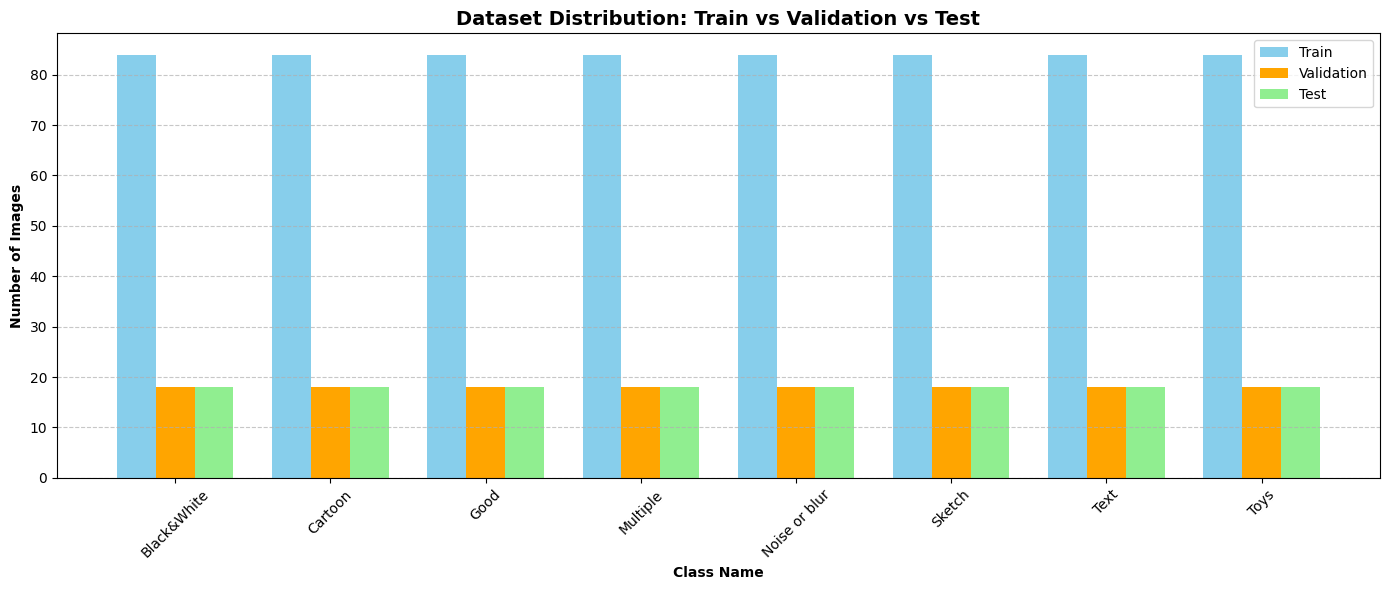

In [ ]:
# 1. פונקציה לספירת תמונות

def count_images_in_dir(directory, class_indices):
    counts = {}
    for class_name in class_indices.keys():
        class_path = os.path.join(directory, class_name)
        if os.path.exists(class_path):
            # ספירת קבצים בלבד
            counts[class_name] = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
        else:
            counts[class_name] = 0
    return counts

# 2. ביצוע הספירה (Train vs Val vs Test)

classes = list(train_gen.class_indices.keys())
indices = train_gen.class_indices

# ספירה בפועל מהתיקיות
train_counts_map = count_images_in_dir(TRAIN_DIR, indices)
val_counts_map = count_images_in_dir(VAL_DIR, indices)
test_counts_map = count_images_in_dir(TEST_DIR, indices)

# המרה לרשימות לצורך הציור
train_values = [train_counts_map[c] for c in classes]
val_values = [val_counts_map[c] for c in classes]
test_values = [test_counts_map[c] for c in classes]

# 3. הדפסת טבלה מסודרת

print(f"{'Class':<20} | {'Train':<10} | {'Val':<10} | {'Test':<10}")
print("-" * 58)
for c, t, v, te in zip(classes, train_values, val_values, test_values):
    print(f"{c:<20} | {t:<10} | {v:<10} | {te:<10}")

# 4. ציור גרף השוואתי

x = np.arange(len(classes))  # מיקומי הברים
width = 0.25                 # רוחב הברים (מותאם ל-3 עמודות)

plt.figure(figsize=(14, 6))

# ברים של ה-Train
plt.bar(x - width, train_values, width, label='Train', color='skyblue')
# ברים של ה-Val
plt.bar(x, val_values, width, label='Validation', color='orange')
# ברים של ה-Test
plt.bar(x + width, test_values, width, label='Test', color='lightgreen')

plt.xlabel('Class Name', fontweight='bold')
plt.ylabel('Number of Images', fontweight='bold')
plt.title('Dataset Distribution: Train vs Validation vs Test', fontsize=14, fontweight='bold')
plt.xticks(x, classes, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# **הרצת המודל**

In [ ]:
from tensorflow.keras import layers, models, optimizers

# --- הגדרת המודל: SANITY CHECK (בדיקת שינון) ---
# שימוש באותם פרמטרים של המודל הטוב ביותר משלב 2

UNITS = 1024

LR = 0.0001

EPOCHS = 25

print(f"מתחיל ריצת Sanity Check: יחידות={UNITS}, ללא Dropout, ללא Callbacks")

# 1. בניית המודל

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.Flatten()(x)
x = layers.Dense(UNITS, activation='relu', name='custom_dense')(x)

output_layer = layers.Dense(len(class_names), activation='softmax', name='prediction')(x)

step1_model = models.Model(inputs=base_model.input, outputs=output_layer, name="VGG16_Step1Model")

step1_model.compile(optimizer=optimizers.Adam(learning_rate=LR),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# step1_model.summary()

# 2. אימון

print("מתחיל אימון ...")

history = step1_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    verbose=1
)

🚀 מתחיל ריצת Sanity Check: יחידות=1024, ללא Dropout, ללא Callbacks
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
🚀 מתחיל אימון ...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 645s 30s/step - accuracy: 0.3620 - loss: 1.9835 - val_accuracy: 0.7500 - val_loss: 0.6956
Epoch 2/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 409ms/step - accuracy: 0.8801 - loss: 0.3844 - val_accuracy: 0.8472 - val_loss: 0.5577
Epoch 3/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 386ms/step - accuracy: 0.9742 - loss: 0.1636 - val_accuracy: 0.8472 - val_loss: 0.4958
Epoch 4/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 415ms/step - accuracy: 0.9944 - loss: 0.0618 - val_accuracy: 0.8750 - val_loss: 0.4594
Epoch 5/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 420ms/step - accuracy: 0.9984 - loss: 0.0391 - val_accuracy: 0.8681 - val_loss: 0.4720
Epoch 6/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 391ms/step - accuracy: 1.0000 - loss: 0.0275 - val_accuracy: 0.8681 - val_loss: 0.4506
Epoch 7/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 415ms/step - accuracy: 1.0000 - loss: 0.0195 - val_accuracy: 0.8611 - val_loss: 0.4591
Epoch 8/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 391ms/step - accuracy: 1.0000 - loss: 0.0147 - val_accuracy: 0.

# **גרפי וויזואליזציה סופית**

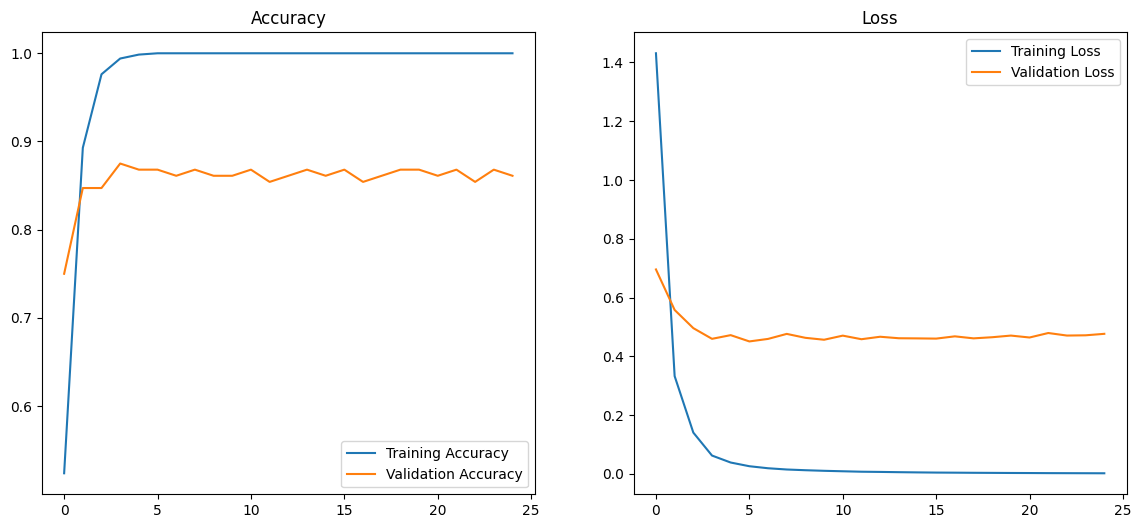

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Loss')
plt.show()


# **הצגת מטריצות ואחוזי הצלחה**

מכין גנרטורים לבדיקה (Train + Val)...
Found 672 images belonging to 8 classes.
Found 144 images belonging to 8 classes.

מעבד תחזיות עבור: TRAIN Set...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 319ms/step


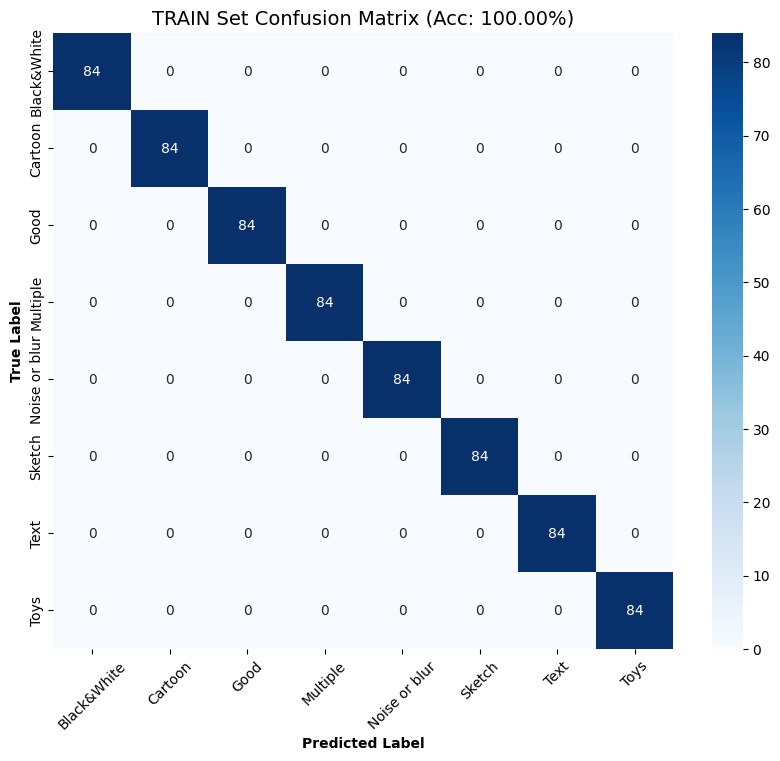


מעבד תחזיות עבור: VALIDATION Set...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step


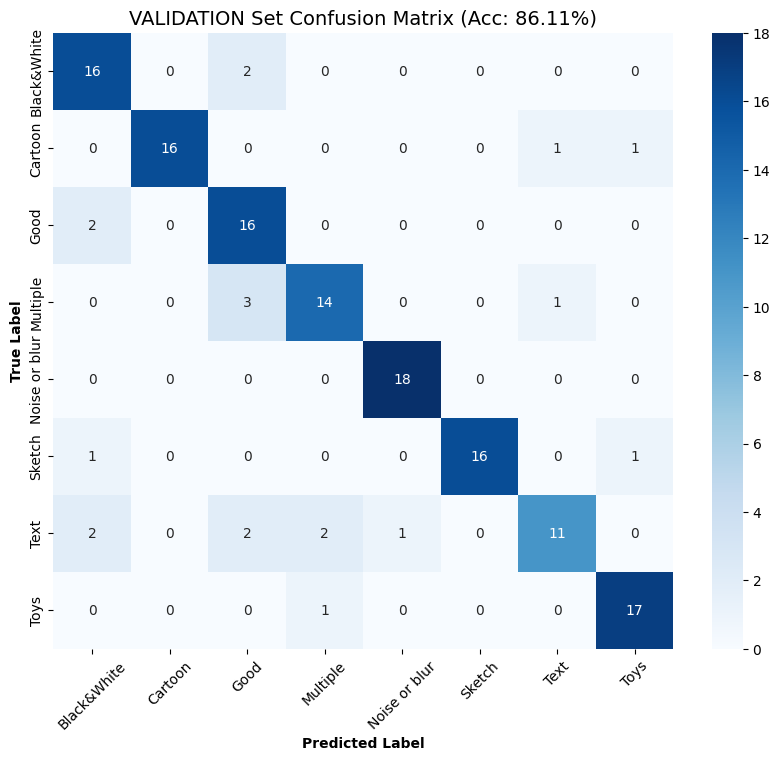


 מכין תצוגה ויזואלית של טעויות והצלחות...


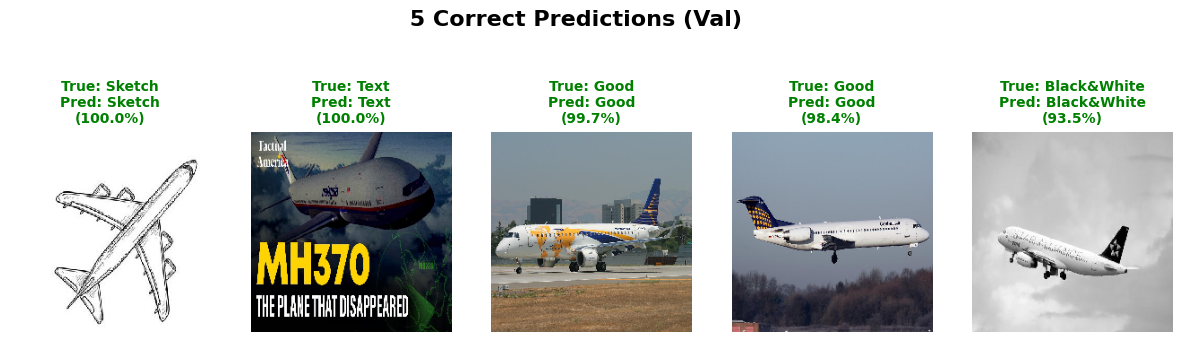

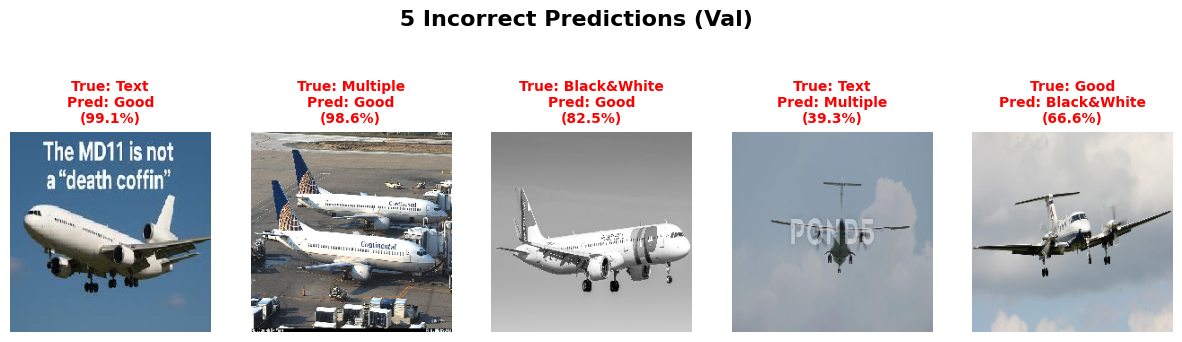

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. הכנת נתונים ללא ערבוב

print("מכין גנרטורים לבדיקה (Train + Val)...")

eval_datagen = ImageDataGenerator(rescale=1./255)

# גנרטור TRAIN (לבדיקת שינון)
train_gen_eval = eval_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

# גנרטור VAL (לבדיקת ביצועים)
val_gen_eval = eval_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

# שמות המחלקות
class_names = list(train_gen_eval.class_indices.keys())

# 2. פונקציה לחישוב והצגת מטריצה

def analyze_and_plot(generator, title_set):
    print(f"\nמעבד תחזיות עבור: {title_set}...")
    generator.reset()

    # חיזוי
    preds_probs = step1_model.predict(generator, verbose=1)
    y_pred = np.argmax(preds_probs, axis=1)
    y_true = generator.classes

    # חישוב מטריצה ודיוק
    cm = confusion_matrix(y_true, y_pred)
    acc = np.mean(y_true == y_pred)

    # ציור היט-מאפ (Heatmap)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{title_set} Confusion Matrix (Acc: {acc*100:.2f}%)', fontsize=14)
    plt.ylabel('True Label', fontweight='bold')
    plt.xlabel('Predicted Label', fontweight='bold')
    plt.xticks(rotation=45)
    plt.show()

    # החזרת הנתונים כדי להשתמש בהם לתמונות
    return preds_probs, y_pred, y_true

# 3. הרצת הבדיקות (מטריצות)

# א. מטריצה ל-TRAIN
analyze_and_plot(train_gen_eval, "TRAIN Set")

# ב. מטריצה ל-VAL (שומרים את התוצאות להצגת התמונות)
val_probs, val_preds, val_true = analyze_and_plot(val_gen_eval, "VALIDATION Set")

# 4. הצגת תמונות (הצלחות vs כישלונות ב-VAL)

print("\n מכין תצוגה ויזואלית של טעויות והצלחות...")

# טעינת התמונות לזיכרון לתצוגה
val_images = []
val_gen_eval.reset()
for i in range(len(val_gen_eval)):
    batch_imgs, _ = next(val_gen_eval)
    val_images.extend(batch_imgs)
val_images = np.array(val_images)

# אינדקסים
correct_indices = np.where(val_preds == val_true)[0]
incorrect_indices = np.where(val_preds != val_true)[0]

def plot_images_grid(indices, title, is_error=False):
    if len(indices) == 0:
        print(f"אין תמונות להציג עבור: {title}")
        return

    n_show = min(5, len(indices))
    selected_indices = np.random.choice(indices, n_show, replace=False)

    plt.figure(figsize=(15, 4))
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.05)

    for i, idx in enumerate(selected_indices):
        img = val_images[idx]
        true_lbl = class_names[val_true[idx]]
        pred_lbl = class_names[val_preds[idx]]
        conf = np.max(val_probs[idx]) * 100

        col = 'red' if is_error else 'green'

        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.title(f"True: {true_lbl}\nPred: {pred_lbl}\n({conf:.1f}%)", color=col, fontsize=10, fontweight='bold')
        plt.axis("off")
    plt.show()

# הצגה
plot_images_grid(correct_indices, " 5 Correct Predictions (Val)", is_error=False)

if len(incorrect_indices) > 0:
    plot_images_grid(incorrect_indices, " 5 Incorrect Predictions (Val)", is_error=True)
else:
    print("\n המודל צדק ב-100% מהמקרים ב-Validation.")

# **הערכת המודל על סט המבחן**

In [ ]:
# --- הגדרת גנרטור לטסט ---
test_datagen = ImageDataGenerator(rescale=1./255) # רק נרמול, בלי אוגמנטציה

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,  # הנתיב לתיקיית ה-test
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

# --- ביצוע המבחן הסופי ---
print("\n מבצע הערכה על סט הטסט (Test Set)...")
test_loss, test_acc = step1_model.evaluate(test_gen)
print(f"\n דיוק סופי על הטסט: {test_acc*100:.2f}%")

Found 144 images belonging to 8 classes.

 מבצע הערכה על סט הטסט (Test Set)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - accuracy: 0.8164 - loss: 0.5463

 דיוק סופי על הטסט: 85.42%


נערך חיזוי על סט הטסט...
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step


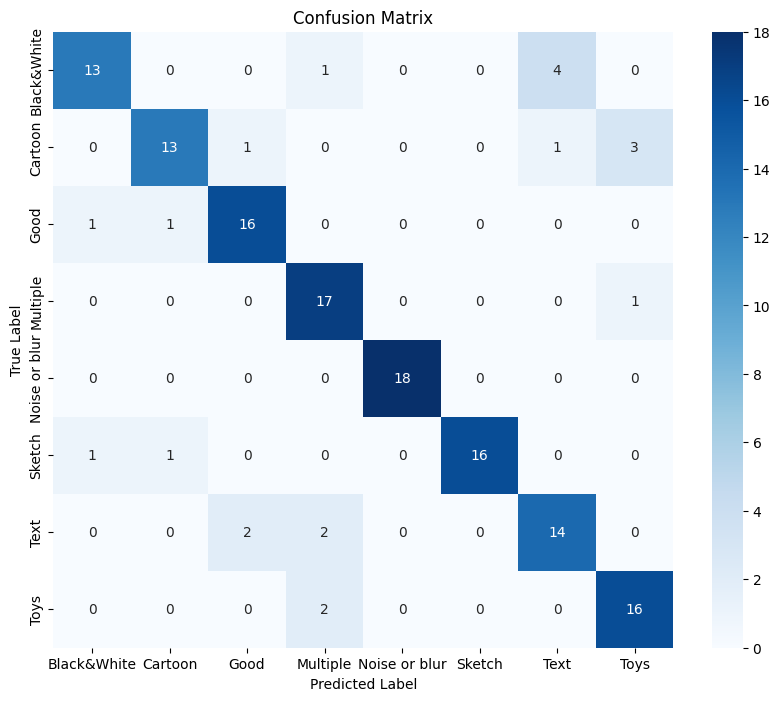


Classification Report:

               precision    recall  f1-score   support

  Black&White       0.87      0.72      0.79        18
      Cartoon       0.87      0.72      0.79        18
         Good       0.84      0.89      0.86        18
     Multiple       0.77      0.94      0.85        18
Noise or blur       1.00      1.00      1.00        18
       Sketch       1.00      0.89      0.94        18
         Text       0.74      0.78      0.76        18
         Toys       0.80      0.89      0.84        18

     accuracy                           0.85       144
    macro avg       0.86      0.85      0.85       144
 weighted avg       0.86      0.85      0.85       144



In [ ]:
# 1. ביצוע חיזוי על כל סט הטסט

print("נערך חיזוי על סט הטסט...")
y_pred_prob = step1_model.predict(test_gen)
y_pred = np.argmax(y_pred_prob, axis=1) # הפיכת הסתברויות למספר מחלקה (0, 1, 2...)
y_true = test_gen.classes # התוויות האמיתיות

# 2. יצירת מטריצת הבלבול

cm = confusion_matrix(y_true, y_pred)

# 3. ציור הגרף

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# 4. דוח טקסטואלי מפורט

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

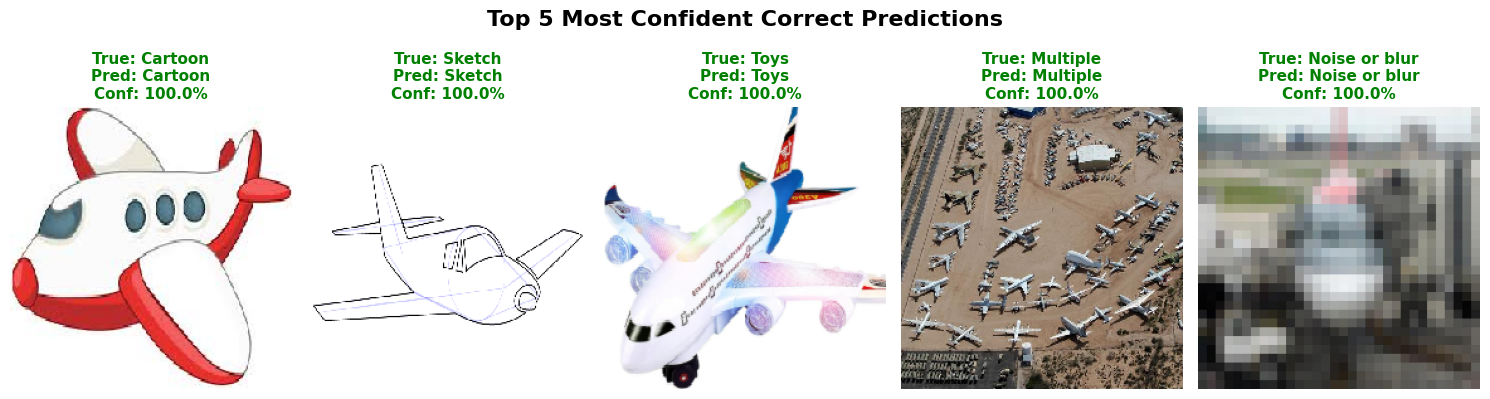

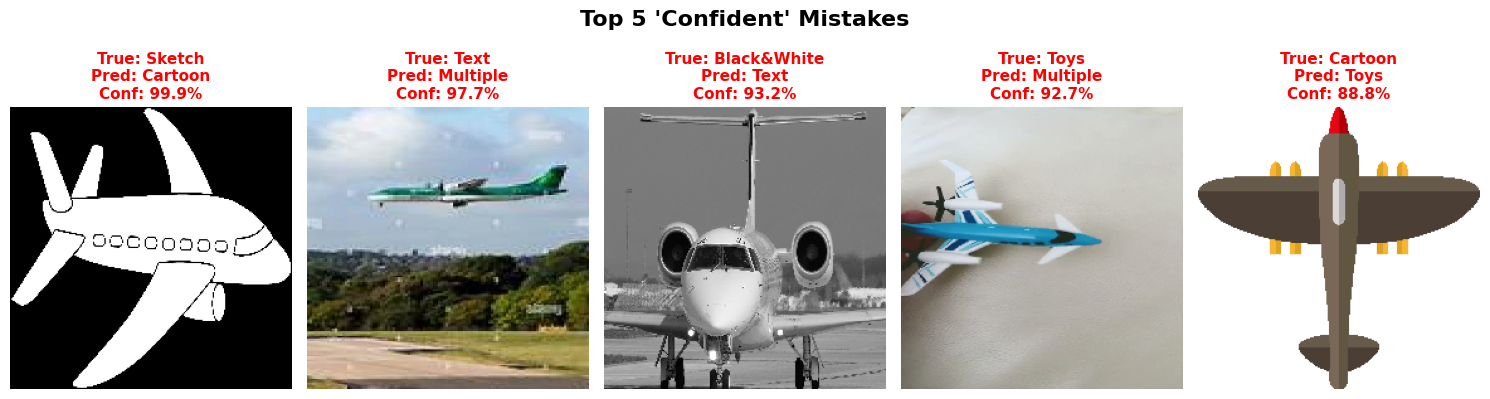

In [ ]:
from tensorflow.keras.preprocessing import image

# 5. הצגת הצלחות וכישלונות (ממוין לפי רמת ביטחון)

# שליפת רשימת הקבצים
file_paths = test_gen.filepaths

# מציאת אינדקסים
correct_indices = np.where(y_pred == y_true)[0]
incorrect_indices = np.where(y_pred != y_true)[0]

# שליפת רמות הביטחון (Confidence) לכל התחזיות
confidences = np.max(y_pred_prob, axis=1)

def plot_sorted_predictions(indices, title, color, sort_descending=True):
    plt.figure(figsize=(15, 4))
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.05)

    if len(indices) == 0:
        print(f"לא נמצאו דוגמאות עבור: {title}")
        return

    # שולפים את הביטחון רק עבור האינדקסים הרלוונטיים
    relevant_confidences = confidences[indices]

    # מיון האינדקסים (Argsort)
    if sort_descending:
        # מהגבוה לנמוך (הכי בטוחים)
        sorted_order = np.argsort(relevant_confidences)[::-1]
    else:
        # מהנמוך לגבוה (הכי פחות)
        sorted_order = np.argsort(relevant_confidences)

    # לוקחים את ה-5 הראשונים אחרי המיון
    top_n_indices = indices[sorted_order[:5]]

    for i, idx in enumerate(top_n_indices):
        img_path = file_paths[idx]
        img = image.load_img(img_path, target_size=(224, 224))

        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        confidence = confidences[idx] * 100

        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%",
                  color=color, fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

# --- הפעלת הפונקציות ---

# 1. ההצלחות הכי גדולות (הכי בטוח בעצמו)
plot_sorted_predictions(correct_indices, "Top 5 Most Confident Correct Predictions", 'green', sort_descending=True)

# 2. הטעויות הכי "קשות" (המודל היה בטוח שהוא צודק, אבל טעה)!
if len(incorrect_indices) > 0:
    plot_sorted_predictions(incorrect_indices, "Top 5 'Confident' Mistakes", 'red', sort_descending=True)
else:
    print("אין טעויות להציג.")

# **הרצת תמונות חדשות מהעולם**

 מציג תוצאות ויזואליות...



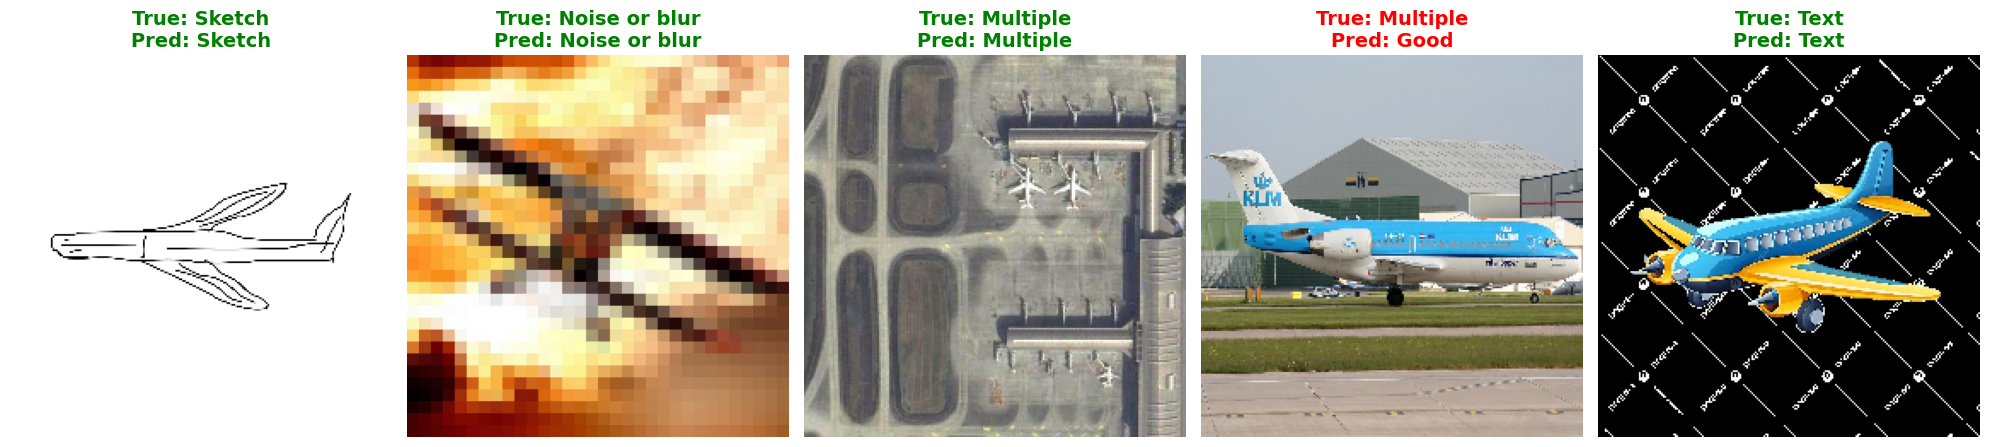

In [ ]:
# קישור לתיקיית מקור
base_dir = "/content/drive/MyDrive/Elbit Project/Images Data for Coding"

# רשימה של זוגות: (שם קובץ, הלייבל האמיתי)
test_data = [
    ('test_image.jpg', 'Sketch'),
    ('test_image2.jpg', 'Noise or blur'),
    ('test_image3.jpg', 'Multiple'),
    ('test_image4.jpg', 'Multiple'),
    ('test_image5.png', 'Text')
]

#  לולאת עיבוד ותצוגה

plt.figure(figsize=(20, 6)) # רוחב גדול
print(" מציג תוצאות ויזואליות...\n")

for i, (file_name, true_label) in enumerate(test_data):
    full_path = os.path.join(base_dir, file_name)

    # 1. בדיקה שהקובץ קיים
    if not os.path.exists(full_path):
        continue

    # 2. טעינה ועיבוד
    img = image.load_img(full_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    img_batch = img_batch / 255.0  # נירמול

    # 3. חיזוי
    probs = step1_model.predict(img_batch, verbose=0)
    pred_idx = np.argmax(probs)
    pred_label = class_names[pred_idx]

    # 4. בדיקת פרדיקציה וקביעת צבע
    is_correct = (pred_label == true_label)
    title_color = 'green' if is_correct else 'red'

    # טקסט לכותרת (לייבל אמיתי לעומת מה המודל חשב)
    title_text = f"True: {true_label}\nPred: {pred_label}"

    # 5. הוספה לגרף
    plt.subplot(1, len(test_data), i+1)
    plt.imshow(img)
    plt.axis('off')

    plt.title(title_text, fontsize=14, color=title_color, fontweight='bold')

# סידור והצגה
plt.tight_layout()
plt.show()